In [37]:
!pip install kagglehub

  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
Using cached kagglehub-1.0.2-py3-none-any.whl (70 kB)

   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   ------------------------------ --------- 3/4 [

In [38]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

100%|██████████| 62.6M/62.6M [00:05<00:00, 13.0MB/s]

Extracting files...


Path to dataset files: C:\Users\jorge\.cache\kagglehub\datasets\datamunge\sign-language-mnist\versions\1


In [39]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

In [42]:
import os

print(os.listdir(path))

train_path = os.path.join(path, "sign_mnist_train.csv")

data = pd.read_csv(train_path)

print(data.head())
print(data.shape)

['american_sign_language.PNG', 'amer_sign2.png', 'amer_sign3.png', 'sign_mnist_test', 'sign_mnist_test.csv', 'sign_mnist_train', 'sign_mnist_train.csv']
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   


In [44]:
labels = data["label"]

data = data.drop(columns="label").to_numpy()

images = data.reshape(-1, 28, 28).astype(np.float32)

print("Imágenes:", images.shape)
print("Etiquetas:", labels.shape)

Imágenes: (27455, 28, 28)
Etiquetas: (27455,)


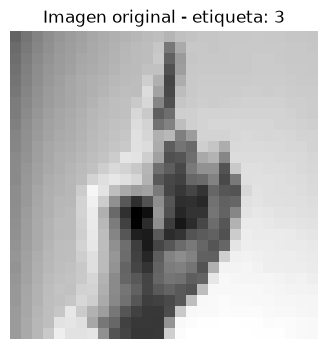

In [45]:
image = images[0]

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Imagen original - etiqueta: {labels.iloc[0]}")
plt.axis("off")
plt.show()

In [46]:
image_tensor = torch.tensor(image).unsqueeze(0)

print(image_tensor.shape)

torch.Size([1, 28, 28])


In [47]:
rotation = transforms.RandomRotation(degrees=30)

In [48]:
translation = transforms.RandomAffine(
    degrees=0,
    translate=(0.2, 0.2)
)

In [49]:
scaling = transforms.RandomAffine(
    degrees=0,
    scale=(0.7, 1.3)
)

In [50]:
inversion = transforms.RandomInvert(p=1.0)

In [51]:
class AddNoise:
    def __init__(self, mean=0.0, std=0.2):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std + self.mean
        return torch.clamp(tensor + noise, 0, 1)

In [52]:
random_crop = transforms.RandomCrop(
    size=24,
    padding=4
)

In [53]:
image_tensor = image_tensor / 255.0

transformed_images = [
    rotation(image_tensor),
    translation(image_tensor),
    scaling(image_tensor),
    inversion(image_tensor),
    AddNoise()(image_tensor),
    random_crop(image_tensor)
]

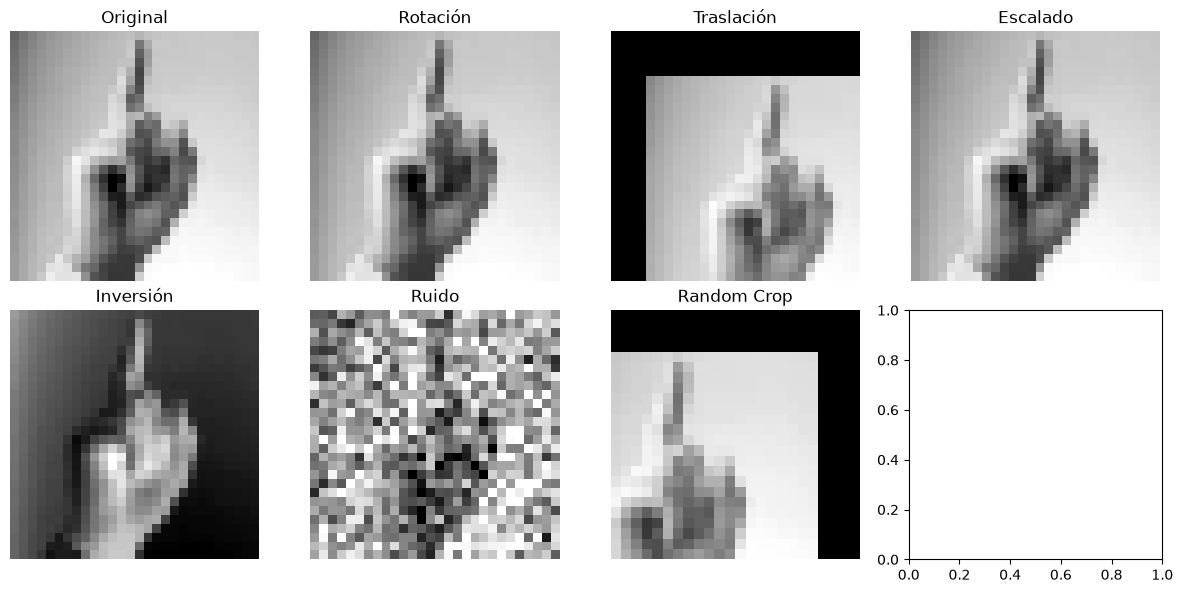

In [54]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Original
axes[0, 0].imshow(image_tensor.squeeze(), cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

titles = [
    "Rotación",
    "Traslación",
    "Escalado",
    "Inversión",
    "Ruido",
    "Random Crop"
]

for ax, img, title in zip(axes.flat[1:], transformed_images, titles):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [55]:
X = torch.tensor(images, dtype=torch.float32)

X = X.unsqueeze(1)

X = X / 255.0

y = torch.tensor(labels.to_numpy(), dtype=torch.long)

print(X.shape)
print(y.shape)

torch.Size([27455, 1, 28, 28])
torch.Size([27455])


In [56]:
mean = X.mean()
std = X.std()

X = (X - mean) / std

print("Media:", X.mean().item())
print("Desviación estándar:", X.std().item())

Media: -2.5697198680063593e-07
Desviación estándar: 1.0


In [57]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)

Entrenamiento: torch.Size([21964, 1, 28, 28])
Validación: torch.Size([5491, 1, 28, 28])


In [58]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [59]:
class CNN(nn.Module):

    def __init__(
        self,
        padding=1,
        stride=1,
        kernel_size=3,
        pooling_kernel=2,
        pooling_stride=2
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )

        self.pool = nn.MaxPool2d(
            kernel_size=pooling_kernel,
            stride=pooling_stride
        )

        self.relu = nn.ReLU()

        # Calculamos automáticamente el tamaño de entrada
        # de la primera capa fully connected
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            dummy = self.pool(self.relu(self.conv1(dummy)))
            dummy = self.pool(self.relu(self.conv2(dummy)))
            flattened_size = dummy.view(1, -1).shape[1]

        self.fc1 = nn.Linear(flattened_size, 128)
        self.fc2 = nn.Linear(128, 25)

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

model = CNN(
    padding=1,
    stride=1,
    kernel_size=3,
    pooling_kernel=2,
    pooling_stride=2
)

model = model.to(device)

print(model)

Dispositivo: cpu
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=25, bias=True)
)


In [61]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 5

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):

    # ==========================
    # ENTRENAMIENTO
    # ==========================

    model.train()

    running_loss = 0.0

    for images_batch, labels_batch in train_loader:

        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images_batch)

        loss = criterion(outputs, labels_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # ==========================
    # VALIDACIÓN
    # ==========================

    model.eval()

    validation_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images_batch, labels_batch in val_loader:

            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images_batch)

            loss = criterion(outputs, labels_batch)

            validation_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels_batch.size(0)

            correct += (predicted == labels_batch).sum().item()

    val_loss = validation_loss / len(val_loader)

    accuracy = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(accuracy)

    print(
        f"Época [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {accuracy:.2f}%"
    )

Época [1/5] | Train Loss: 0.4104 | Val Loss: 0.0484 | Val Accuracy: 98.65%
Época [2/5] | Train Loss: 0.0132 | Val Loss: 0.0008 | Val Accuracy: 100.00%
Época [3/5] | Train Loss: 0.0004 | Val Loss: 0.0003 | Val Accuracy: 100.00%


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Entrenamiento")
plt.plot(val_losses, label="Validación")

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Pérdida durante el entrenamiento")

plt.legend()
plt.grid()

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(val_accuracies, marker="o")

plt.xlabel("Época")
plt.ylabel("Precisión (%)")
plt.title("Precisión en validación")

plt.grid()

plt.show()

In [ ]:
model = CNN(
    padding=0,
    stride=1,
    kernel_size=3,
    pooling_kernel=2,
    pooling_stride=2
)

In [ ]:
model = CNN(
    padding=1,
    stride=1,
    kernel_size=3,
    pooling_kernel=2,
    pooling_stride=2
)

In [ ]:
model = CNN(
    padding=1,
    stride=2,
    kernel_size=3,
    pooling_kernel=2,
    pooling_stride=2
)